# Perceptron Revision

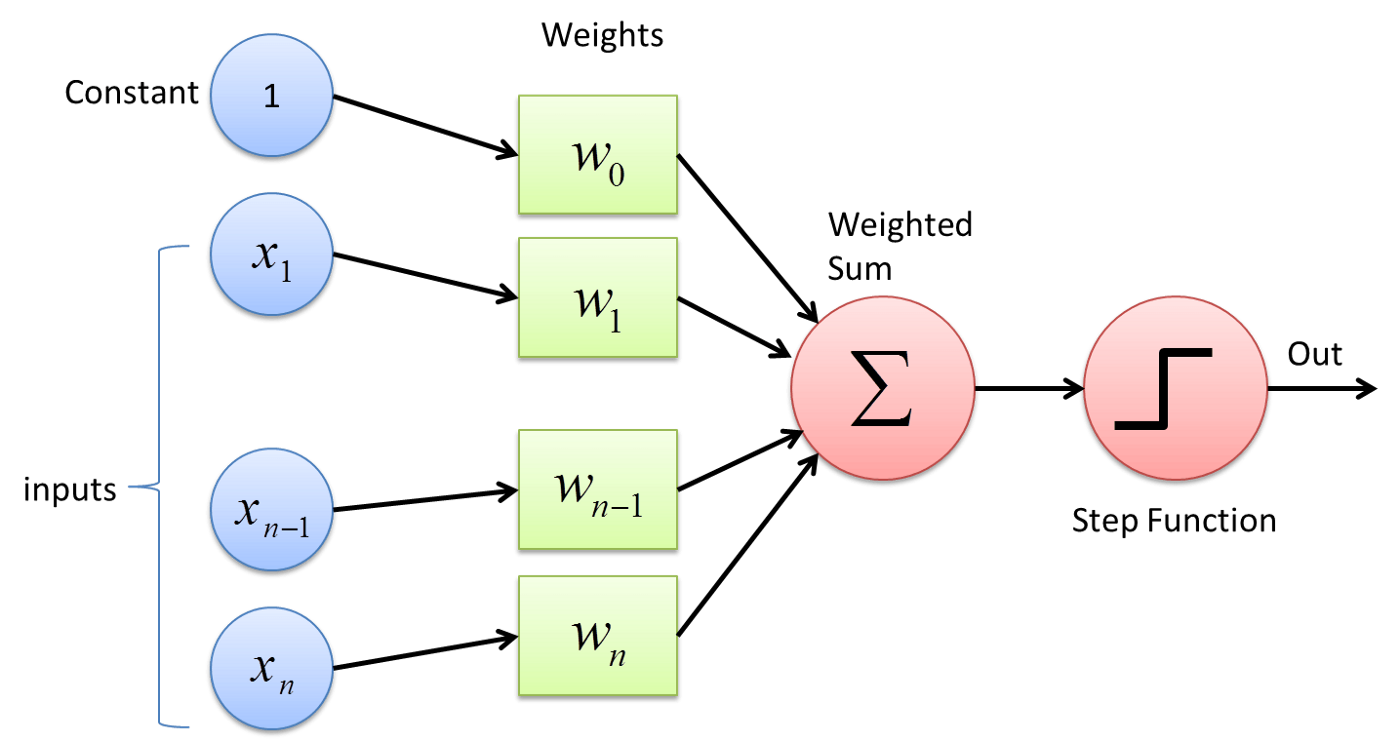

The perceptron calculates the output as follows:
- Multiply the inputs with their corresponding weights
- Calulate the sum of the weighted inputs
- Apply an activation function

# Multi-Layer Perceptron (MLP)

A **Multi-Layer Perceptron (MLP)** is the simplest form of a neural network. It consists of multiple perceptrons, organised in layers:
- *Input Layer*: receives the numerical input features (no. of neurons == no. of features)
- *Hidden Layers*: process information
- *Output Layers*: produces final prediction

A MLP can have any number of hidden layers. In a fully-connected network, every output of the neurons in a layer is connected to every input in the following layer. Thus, the output of the preceding layer serves as the input of the following layer. The original input passes through the MLP until the final output is produced.

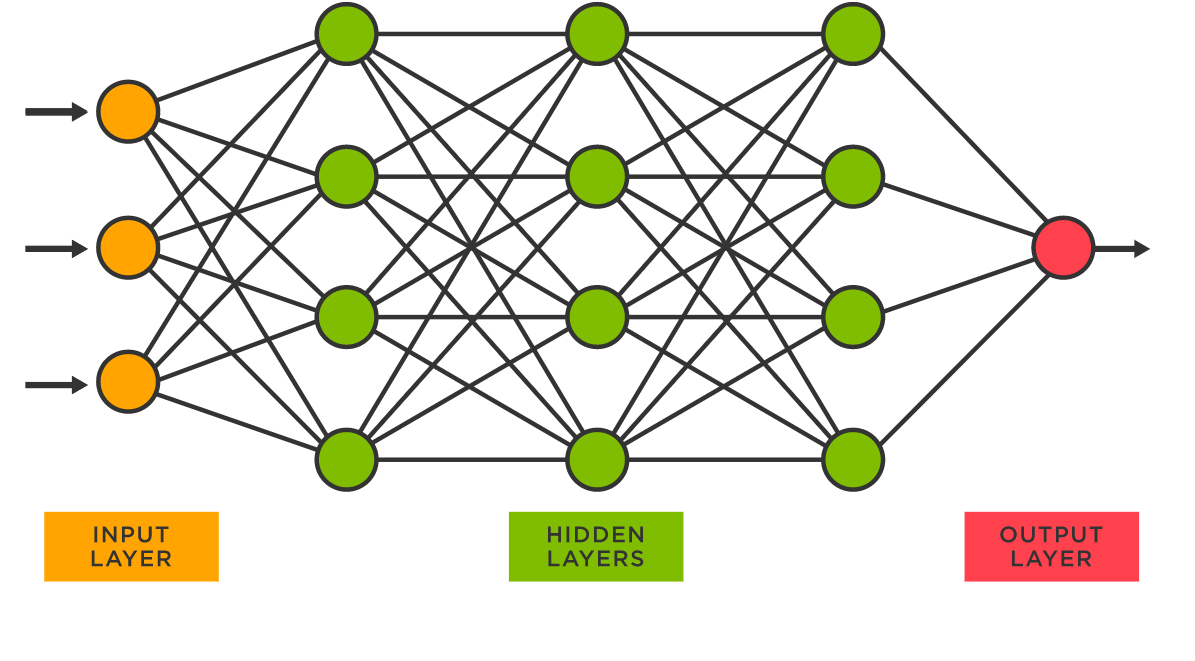

Every layer except the input layer has exactly **one bias term** and as many **weight terms** as there are connections between the layers. The biases and weights of the MLP are the **trainable parameter**, that are optimized during training.

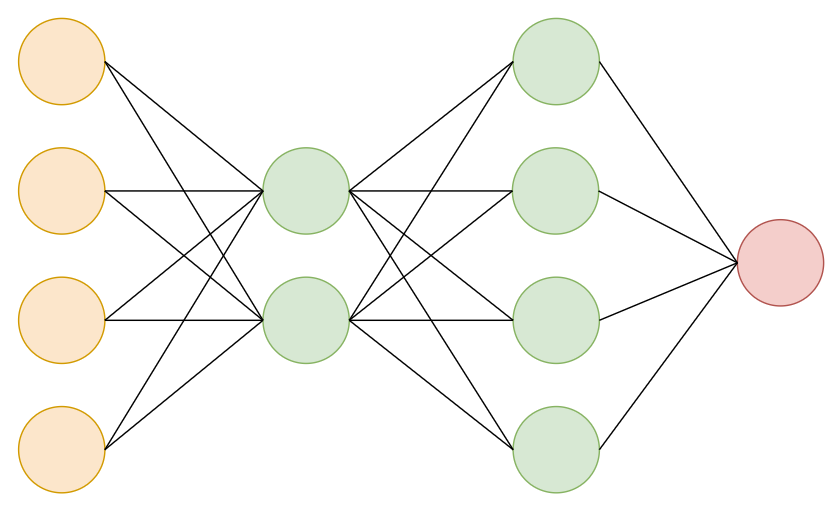

**Question**: How many trainable parameters does the MLP above have?

In [5]:
import torch
import torch.nn as nn

class FirstSimpleMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(4,2),
        nn.ReLU(),
        nn.Linear(2,4),
        nn.ReLU(),
        nn.Linear(4,1)
    )

  def forward(self, x):
    self.model(x)

mlp = FirstSimpleMLP()

# Convolutional Neural Networks

**Convolutional Neural Networks (CNN)** are specially design for images.

## Convolution
A **convolution** applies a filter to the image in the following way:

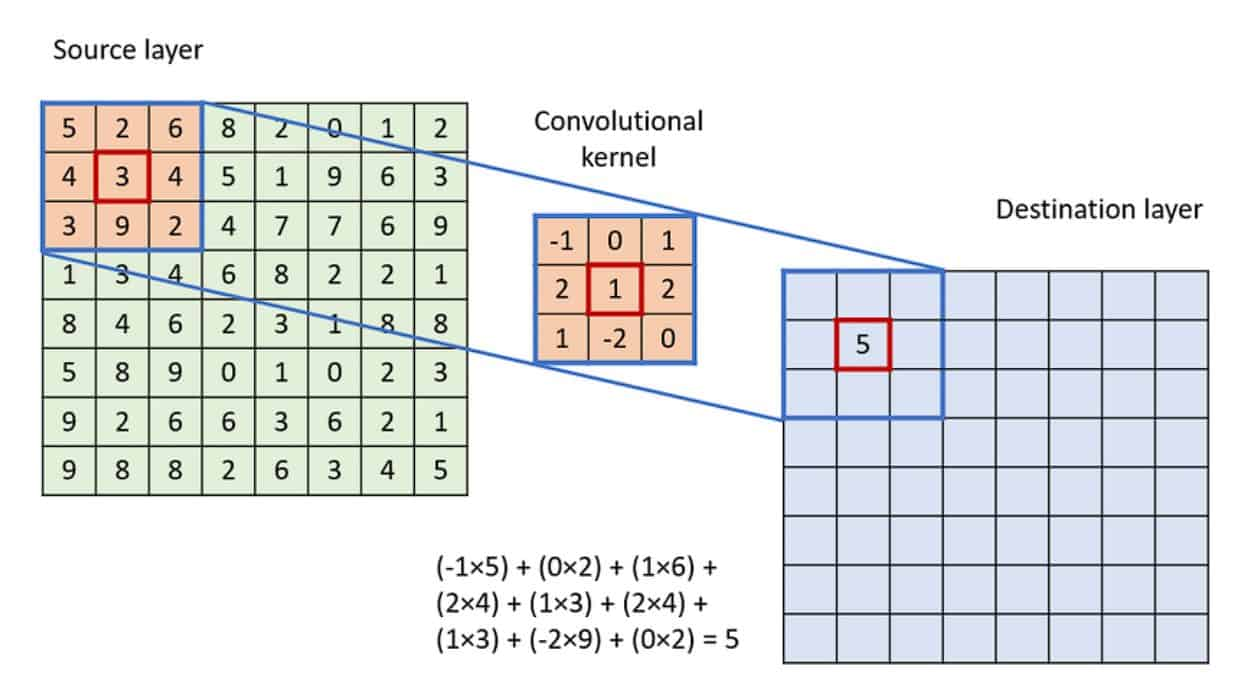

One has to choose a **kernel size** and the **stride** (how much does the kernel move). The kernel hereby detects simple patterns such as Edges, Lines and Corners.

**Questions:**

How can we make sure that the border pixels are also convoluted?

If we apply a 2x2 kernel to a 4x4 image with a stride of 2, how big is the result image?

## Pooling Layers
**Pooling Layers** aim to reduce the parameter size while keeping the information intact. A common pooling operation is MaxPooling:

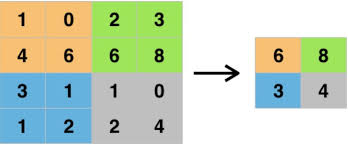

In [ ]:
class FirstSimpleCNN(nn.Module):
  def __init__(self):
    super.__init__()
    self.model = nn.Sequential(
        nn.Conv2D(1,8, kernel_size=2, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2D(8, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Linear(16, 32),
        nn.ReLU()
    )

  def forward(self, x):
    self.model(x)

# CNN-based Document Recognition

Now, we will take a look at how to extract

- Phone Numbers
- Names
- Addresses

from an image of a paper. Therefore, we will use the following pipeline:



## Dataset

For now, we will use the *EMNIST* dataset, which contains handwritten images of digits and upper case letters.

In [ ]:
from torchvision import datasets, transforms

# EMNIST training Data
emnist_train = datasets.EMNIST(
    root="data",
    split="byclass",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 562M/562M [00:03<00:00, 153MB/s]


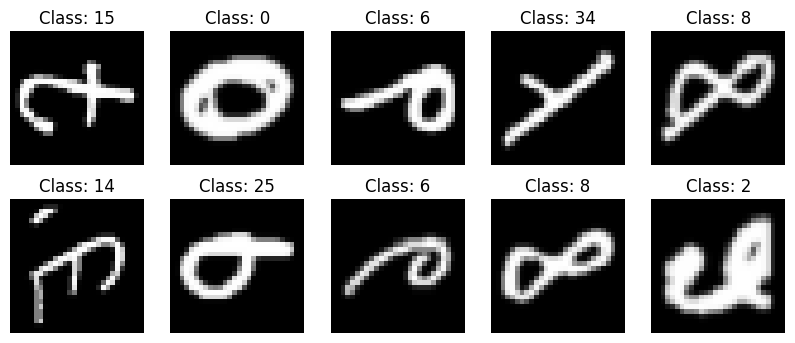

In [ ]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax in axes.flatten():
    img, label = emnist_train[random.randint(0, len(emnist_train) - 1)]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Class: {label}")
    ax.axis("off")

plt.show()

## CNN

In [ ]:
"""
Build the following CNN:
Convolution:
   - 1 input, 32 outputs, kernel size of 3, stride of 1
ReLU and MaxPooling with a size of 2
Convolution:
   - 32 inputs, 64 outputs, kernel size of 3, stride of 1
ReLU and MaxPooling with a size of 2
A flattening layer via nn.Flatten()
A linear layer with ReLU activation (IMPORTANT: use a input number of 64*7*7 and a output number of 256)
A linear output layer (IMPORTANT: use num_classes as output number)
"""
class CharacterCNN(nn.Module):
  def __init__(self, num_classes):
    super.__init__()
    self.model = nn.Sequential(

    )

  def forward(self, x):
    self.model(x)


## Training the model

In [ ]:
from torch.utils.data import DataLoader
import torch.optim as optim

num_classes = 62

train_loader = DataLoader(
    emnist_train,
    batch_size=64,
    shuffle=True
)

model = CharacterCNN(num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
num_epochs = 3

model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        # forward pass + loss
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward pass
        optimizer.zero_grad()
        loss.backward()

        # update weights of the network
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader)}")

Epoch [1/3], Loss: 0.48071398586991204
Epoch [2/3], Loss: 0.3725976500863081
Epoch [3/3], Loss: 0.3465098557618371


## Evaluating the model

In [ ]:
# EMNIST test Data
emnist_test = datasets.EMNIST(
    root="data",
    split="byclass",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)
test_loader = DataLoader(emnist_test, batch_size=32, shuffle=False)

In [ ]:
# evaluation loop
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        predicted = torch.argmax(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on test data: {100 * correct / total:.2f}%")

Accuracy on test data: 86.37%


In [ ]:
torch.save(model.state_dict(), "model_weights.pth")

## MobileNet V3 playground

In [1]:
import torchvision.models as models
from PIL import Image

# large mobilnet
mobilenet_v3_large = models.mobilenet_v3_large(pretrained=True)

# smalle mobilnet
mobilenet_v3_small = models.mobilenet_v3_small(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 132MB/s] 
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 106MB/s]


In [ ]:
from torchvision import transforms

# ImageNet preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img = Image.open("YOU_IMAGE.jpg").convert("RGB")
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)

with torch.no_grad():
    output = mobilenet_v3_small(input_batch)

predicted_class = torch.argmax(output, dim=1).item()
print("Predicted class index:", predicted_class)

Predicted class index: 254
